[CACHE] Loading pre-extracted GDELT dataset from 'ccg_events_backup.csv'...
Loaded 1058 Chinese Coast Guard conflict records (2015–Present).



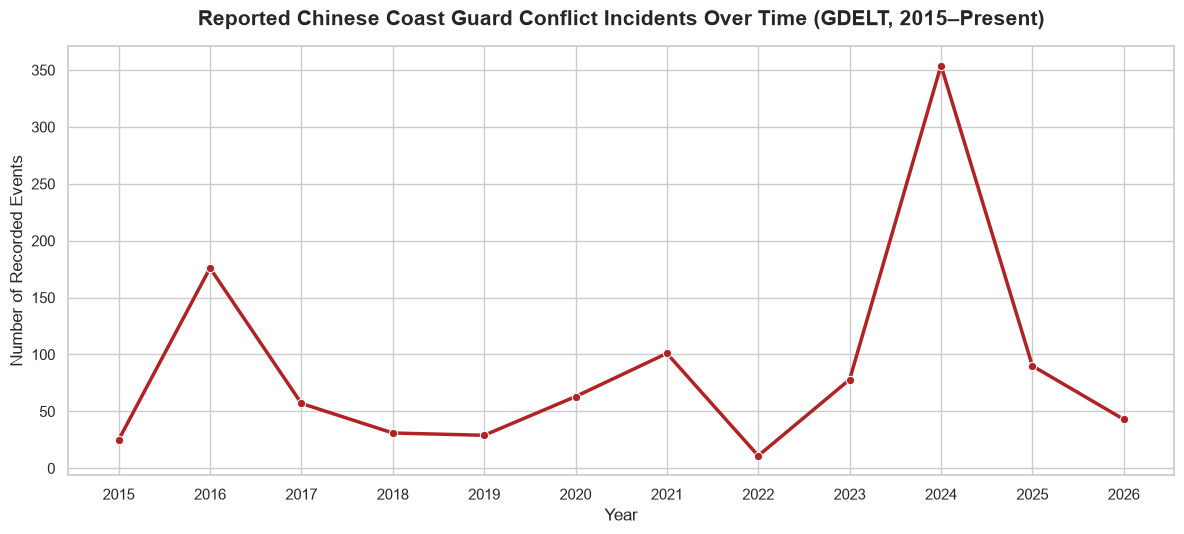

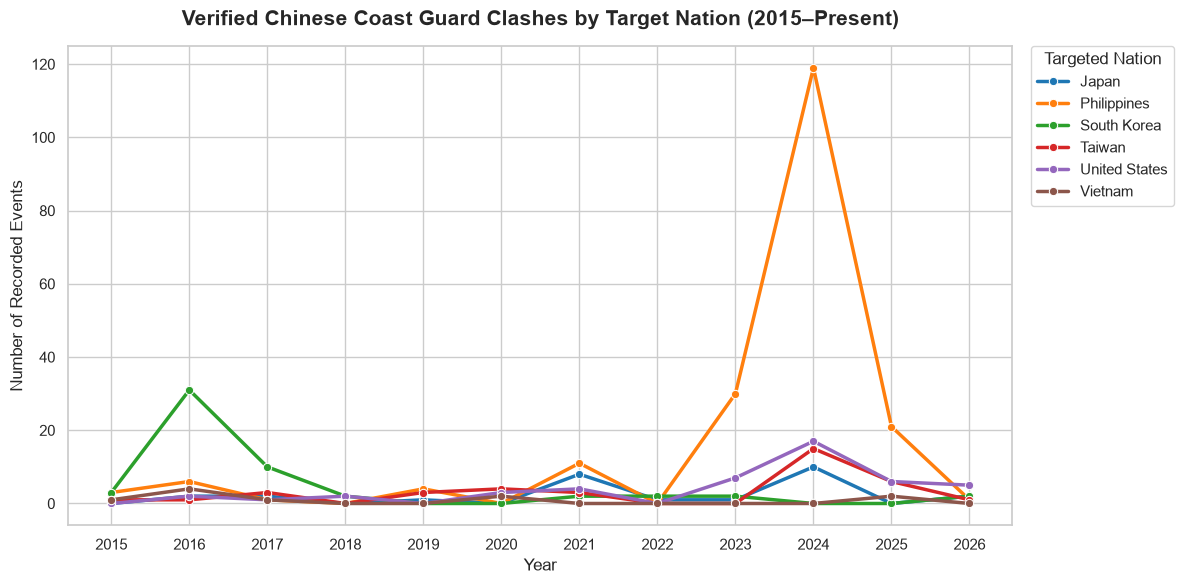

In [3]:
# ==============================================================================
# Indo-Pacific Maritime Conflict Tracker (GDELT 2.0)
# Dependencies: pip install pandas matplotlib seaborn google-cloud-bigquery
# ==============================================================================

import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================================================================
# 1. DATA INGESTION (LOCAL CACHE FALLBACK OR BIGQUERY)
# ==============================================================================
CACHE_FILE = "ccg_events_backup.csv"
CREDENTIAL_PATH = "service_account.json"

query_actors = """
SELECT
    Year,
    Actor1Name,
    Actor2Name,
    ActionGeo_CountryCode
FROM
    `gdelt-bq.gdeltv2.events`
WHERE
    Year >= 2015
    AND (Actor1CountryCode = 'CHN' OR Actor2CountryCode = 'CHN')
    AND (Actor1Name LIKE '%COAST GUARD%' OR Actor2Name LIKE '%COAST GUARD%')
    AND EventRootCode IN ('17', '18', '19')
"""

if os.path.exists(CACHE_FILE):
    print(f"[CACHE] Loading pre-extracted GDELT dataset from '{CACHE_FILE}'...")
    df_raw = pd.read_csv(CACHE_FILE)
    print(f"Loaded {len(df_raw)} Chinese Coast Guard conflict records (2015–Present).\n")
else:
    from google.cloud import bigquery
    if os.path.exists(CREDENTIAL_PATH):
        os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = CREDENTIAL_PATH
    client = bigquery.Client()
    print("Querying GDELT 2.0 database via Google BigQuery...")
    df_raw = client.query(query_actors).to_dataframe()
    df_raw.to_csv(CACHE_FILE, index=False)
    print(f"Downloaded and cached {len(df_raw)} total events.\n")

# ==============================================================================
# 2. CHART 1: REPORTED INCIDENTS OVER TIME (2015–PRESENT)
# ==============================================================================
annual_incidents = df_raw.groupby('Year').size().reset_index(name='Incident_Count')

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 5.5))

sns.lineplot(
    data=annual_incidents,
    x='Year',
    y='Incident_Count',
    marker='o',
    color='#b22222',
    linewidth=2.5
)

plt.title('Reported Chinese Coast Guard Conflict Incidents Over Time (GDELT, 2015–Present)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Recorded Events', fontsize=12)
plt.xticks(range(int(annual_incidents['Year'].min()), int(annual_incidents['Year'].max()) + 1))
plt.tight_layout()
plt.show()

# ==============================================================================
# 3. ISOLATE TRUE INTERNATIONAL RIVALS & REMOVE DATELINE BIAS
# ==============================================================================
df = df_raw.copy()
df['Actor1Name'] = df['Actor1Name'].fillna('').str.upper()
df['Actor2Name'] = df['Actor2Name'].fillna('').str.upper()
df['GeoCode'] = df['ActionGeo_CountryCode'].fillna('').str.upper()

# Keyword and FIPS 10-4 Country Code mapping
rival_mapping = {
    'Philippines':   {'keywords': ['PHILIPPIN', 'MANILA'], 'fips': 'RP'},
    'Vietnam':       {'keywords': ['VIETNAM', 'HANOI'], 'fips': 'VM'},
    'Japan':         {'keywords': ['JAPAN', 'TOKYO', 'SENKAKU'], 'fips': 'JA'},
    'Taiwan':        {'keywords': ['TAIWAN', 'TAIPEI'], 'fips': 'TW'},
    'United States': {'keywords': ['UNITED STATES', 'U.S.', 'AMERICA'], 'fips': 'US'},
    'South Korea':   {'keywords': ['KOREA', 'SEOUL'], 'fips': 'KS'}
}

def identify_true_rival(row):
    combined_actors = f"{row['Actor1Name']} {row['Actor2Name']}"
    for country, identifiers in rival_mapping.items():
        if row['GeoCode'] == identifiers['fips']:
            return country
        for kw in identifiers['keywords']:
            if kw in combined_actors:
                return country
    return 'Domestic / Other'

df['Opposing_Actor'] = df.apply(identify_true_rival, axis=1)

# Strip out domestic Chinese events
df_international = df[df['Opposing_Actor'] != 'Domestic / Other'].copy()
yearly_trends = (
    df_international.groupby(['Year', 'Opposing_Actor'])
    .size()
    .unstack(fill_value=0)
    .stack()
    .reset_index(name='Incident_Count')
)

# ==============================================================================
# 4. CHART 2: MULTI-LINE VISUALIZATION BY TARGET NATION
# ==============================================================================
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=yearly_trends,
    x='Year',
    y='Incident_Count',
    hue='Opposing_Actor',
    marker='o',
    linewidth=2.5,
    palette='tab10'
)

plt.title('Verified Chinese Coast Guard Clashes by Target Nation (2015–Present)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Recorded Events', fontsize=12)

min_year = int(yearly_trends['Year'].min())
max_year = int(yearly_trends['Year'].max())
plt.xticks([min_year] if min_year == max_year else range(min_year, max_year + 1))

plt.legend(title='Targeted Nation', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()